# Resting-state EEG topographic clustering

In [17]:
import matplotlib.pyplot as plt
import mne
import numpy as np
import os

from scipy.signal import find_peaks
from sklearn.cluster import HDBSCAN
from sklearn.decomposition import PCA

%matplotlib inline

## Read EEG data

In [18]:
data_dir = "C:/Users/z3528600/OneDrive - UNSW/data/eeg/mpilmbb/pycrostates_2-20/data"
#data_dir = r"C:\Users\jjjyl\Downloads\pycrostates_2-20\pycrostates_2-20\data"
files = os.listdir(data_dir)
files = [f for f in files if '_EC_' in f] # eyes-closed (EC) files only
subjects = np.unique([f.split('_')[0] for f in files])
print(f"Found n={len(subjects):d} subjects")
print(subjects)

Found n=201 subjects
['sub-010002' 'sub-010003' 'sub-010004' 'sub-010005' 'sub-010006'
 'sub-010007' 'sub-010010' 'sub-010012' 'sub-010016' 'sub-010017'
 'sub-010019' 'sub-010020' 'sub-010021' 'sub-010022' 'sub-010023'
 'sub-010024' 'sub-010026' 'sub-010027' 'sub-010028' 'sub-010029'
 'sub-010030' 'sub-010031' 'sub-010032' 'sub-010033' 'sub-010034'
 'sub-010035' 'sub-010036' 'sub-010037' 'sub-010038' 'sub-010039'
 'sub-010040' 'sub-010041' 'sub-010042' 'sub-010044' 'sub-010045'
 'sub-010046' 'sub-010047' 'sub-010048' 'sub-010049' 'sub-010050'
 'sub-010051' 'sub-010052' 'sub-010053' 'sub-010056' 'sub-010059'
 'sub-010060' 'sub-010061' 'sub-010062' 'sub-010063' 'sub-010064'
 'sub-010065' 'sub-010066' 'sub-010067' 'sub-010068' 'sub-010069'
 'sub-010070' 'sub-010071' 'sub-010072' 'sub-010073' 'sub-010074'
 'sub-010075' 'sub-010076' 'sub-010079' 'sub-010080' 'sub-010081'
 'sub-010083' 'sub-010084' 'sub-010085' 'sub-010086' 'sub-010088'
 'sub-010089' 'sub-010090' 'sub-010091' 'sub-010092' 's

In [19]:
subj = "sub-010194" # which subject
i_ep = 0 # which epoch?
fname = f"{data_dir:s}/{subj:s}_EC_avgref_1-30Hz_ep{i_ep:02d}_raw.fif"
print(f"Filename: {fname:s}")
if os.path.isfile(fname):
    print(f"OK, file exists...")
else:
    print("This file does not exist...")

Filename: C:/Users/z3528600/OneDrive - UNSW/data/eeg/mpilmbb/pycrostates_2-20/data/sub-010194_EC_avgref_1-30Hz_ep00_raw.fif
OK, file exists...


In [21]:
raw = mne.io.read_raw(fname, preload=True)
#raw.set_eeg_reference(['Cz'])

Opening raw data file C:/Users/z3528600/OneDrive - UNSW/data/eeg/mpilmbb/pycrostates_2-20/data/sub-010194_EC_avgref_1-30Hz_ep00_raw.fif...
    Range : 0 ... 16158 =      0.000 ...    64.632 secs
Ready.
Reading 0 ... 16158  =      0.000 ...    64.632 secs...


In [22]:
raw.plot()

Channels marked as bad:
none


## Extract clustering data at GFP peaks

In [23]:
data = raw.get_data()
print(data.shape)

(61, 16159)


In [24]:
gfp = np.std(data, axis=0)
print(gfp.shape)

(16159,)


In [25]:
gfp_peak_indices, gfp_peak_props = find_peaks(
    gfp, 
    height=np.min(gfp),       # Minimum absolute height required for a peak
    distance=5,       # Minimum horizontal distance (in samples) between peaks
    prominence=0.    # How much a peak stands out relative to its surroundings
)
print(f"Number of GFP peaks detected: {len(gfp_peak_indices):d}")

Number of GFP peaks detected: 1399


Sampling rate: 250.0 Hz, dt=4.0 ms


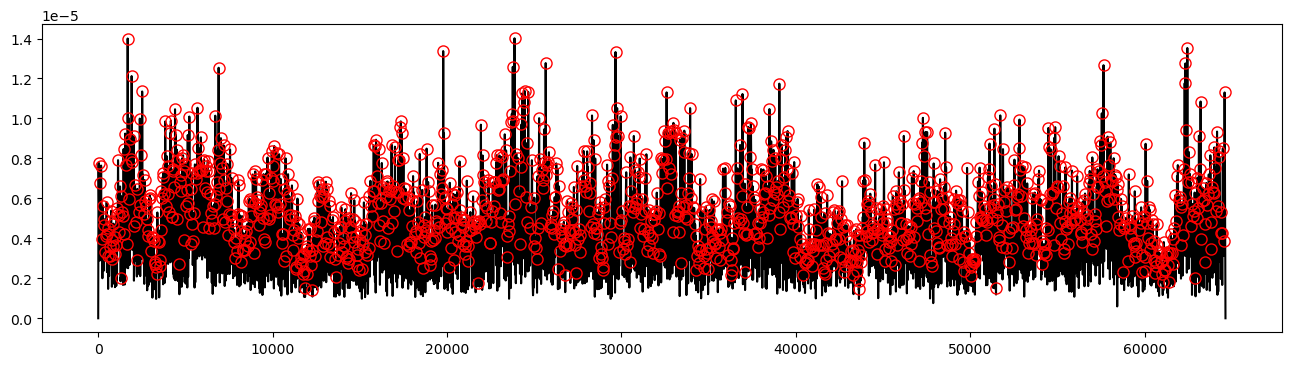

In [26]:
fs = raw.info['sfreq'] # sampling rate
dt = 1000/fs # sampling interval in ms
print(f"Sampling rate: {fs:.1f} Hz, dt={dt:.1f} ms")
time = dt*np.arange(data.shape[1])
plt.figure(figsize=(16,4))
plt.plot(time, gfp, '-k')
plt.plot(time[gfp_peak_indices], gfp[gfp_peak_indices], 'or', ms=8, mfc='none')
plt.show()

In [27]:
X = data[:,gfp_peak_indices].T
print(f"Clustering data X shape: ", X.shape)

Clustering data X shape:  (1399, 61)


## HDBScan clutering

### Sweep `min_cluster_size` to see effect on cluster count

In [28]:
# min_cluster_size is the main lever on how many clusters HDBSCAN finds:
# smaller -> more, finer-grained clusters; larger -> fewer, coarser clusters.
min_cluster_sizes = [3, 5, 7, 8, 10, 20, 30, 50, 100, 150, 200]

print(f"{'min_cluster_size':>17s}  {'n_clusters':>10s}  {'n_noise':>8s}")
for mcs in min_cluster_sizes:
    hdb_sweep = HDBSCAN(copy=True, min_cluster_size=mcs)
    hdb_sweep.fit(X)
    sweep_labels = hdb_sweep.labels_
    n_clusters_sweep = len(np.unique(sweep_labels[sweep_labels > -1]))
    n_noise = np.sum(sweep_labels == -1)
    print(f"{mcs:>17d}  {n_clusters_sweep:>10d}  {n_noise:>8d}")

 min_cluster_size  n_clusters   n_noise
                3           2        61
                5           2       637
                7           2       694
                8           2       703
               10           2       704
               20           2       797
               30           2       842
               50           2       825
              100           2       785
              150           2       831
              200           0      1399


In [29]:
mcs_selected = 20
hdb = HDBSCAN(copy=True, min_cluster_size=mcs_selected)
hdb.fit(X)
labels = hdb.labels_
unique_labels = np.unique(labels)
n_unique_labels = len(unique_labels)
n_clusters = len(np.unique(labels[labels > -1]))
n_noise = np.sum(labels == -1)
print(f"{mcs:>17d}  {n_clusters:>10d}  {n_noise:>8d}")

              200           2       797


## Project on 2D PCA

In [30]:
do_PCA = True

if do_PCA:
    pca = PCA(n_components=2)
    pca.fit(X)
    X2d = pca.transform(X) # transform GFP peaks
else:
    X2d = X
print(X2d.shape)

(1399, 2)


Colors: N=2
n_noise=797, n_clustered=602


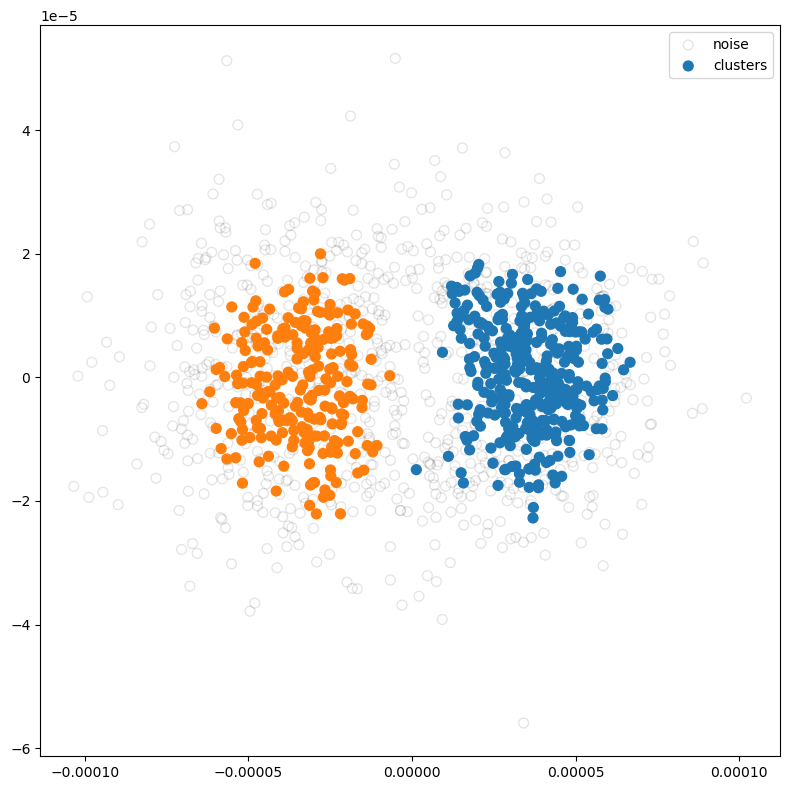

In [31]:
# Qualitative colormap for good categorical contrast between clusters
# (tab10/tab20 are designed for this, unlike hsv whose evenly-spaced hues
# aren't perceptually uniform). Noise (-1) is handled separately below.
N = n_unique_labels - 1 if -1 in unique_labels else n_unique_labels
if N <= 10:
    colors = plt.colormaps['tab10'](np.arange(N))
elif N <= 20:
    colors = plt.colormaps['tab20'](np.arange(N))
else:
    colors = plt.colormaps['hsv'](np.linspace(0, 1, N))
print(f"Colors: N={N:d}")

noise_mask = labels == -1
print(f"n_noise={np.sum(noise_mask):d}, n_clustered={np.sum(~noise_mask):d}")

plt.figure(figsize=(8,8))

# noise: empty markers, black edge
plt.scatter(X2d[noise_mask, 0], X2d[noise_mask, 1],
            facecolors='none', edgecolors='black', s=50, 
            alpha=0.1, label='noise')

# clustered points: filled with their cluster's color
cluster_colors = [colors[k] for k in labels[~noise_mask]]
plt.scatter(X2d[~noise_mask, 0], X2d[~noise_mask, 1],
            c=cluster_colors, s=50, label='clusters')

plt.legend()
plt.tight_layout()
plt.show()

## Cluster centroid topographies

Centroids shape: (2, 61)


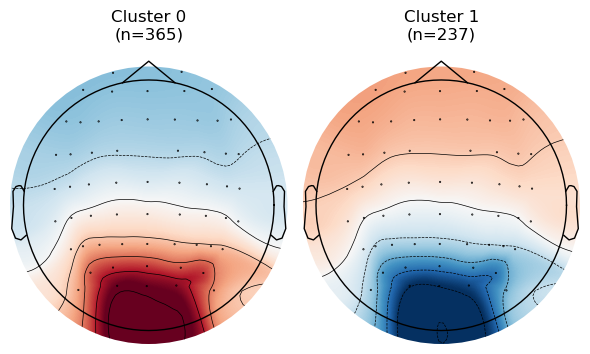

In [32]:
# Cluster centroid = mean sensor-space topography of GFP-peak samples assigned
# to that cluster (noise, label -1, excluded).
cluster_labels_sorted = np.unique(labels[labels > -1])
K = len(cluster_labels_sorted)
centroids = np.array([X[labels == k].mean(axis=0) for k in cluster_labels_sorted])
print(f"Centroids shape: {centroids.shape}")  # (K, n_channels)

fig, axes = plt.subplots(1, K, figsize=(3 * K, 3.5))
if K == 1:
    axes = [axes]

for k, centroid, ax in zip(cluster_labels_sorted, centroids, axes):
    mne.viz.plot_topomap(centroid, raw.info, axes=ax, show=False)
    ax.set_title(f"Cluster {k:d}\n(n={np.sum(labels == k):d})")

fig.tight_layout()
plt.show()